In [119]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.constants import mu_0


In [120]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


In [121]:
def conversion(I):
    """
    Convierte corriente en amperios → campo B en teslas.
    Usa promedios de calibración en mT/A.
    """
    valores = np.array([0.1/0.14, 25.4/1.49, 56.3/3.14])
    promedio_conversion = np.mean(valores)  

    B_mT = I * promedio_conversion       
    return B_mT * 1e-3                      

def B_to_H(B_tesla):
    """
    Convierte campo B (teslas) → campo H (A/m)
    """
    return B_tesla / mu_0 



In [ ]:
def plot_secuencia_datos(
        x, y,
        titulo="Secuencia de Toma de Datos",
        xlabel="Posición X",
        ylabel="Posición Y",
        color_arrows="black",
        color_points="#D6259B",
        arrow_scale=0.25,   # tamaño relativo de flechas
        point_size=40,
        xlim=None,
        ylim=None):

    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor("#F7F9FB")

    # Dibujar flechas pequeñas y finas
    for i in range(len(x) - 1):
        ax.annotate(
            "",
            xy=(x[i+1], y[i+1]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="-|>", 
                lw=1.2,
                color=color_arrows,
                shrinkA=arrow_scale,
                shrinkB=arrow_scale
            )
        )
    
    # Puntos
    ax.scatter(
        x, y,
        s=point_size,
        color=color_points,
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
    )
    

    ax.set_title(titulo, fontsize=16, weight="bold")
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, alpha=0.25)
    
    # Límites opcionales
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    # Bordes sutiles
    for spine in ax.spines.values():
        spine.set_color("#444")
        spine.set_linewidth(0.8)

    plt.show()


In [123]:
hierro = leer_columnas('Hierro.txt')
niquel = leer_columnas('Niquel.txt')

C:\Users\user\AppData\Local\Temp\ipykernel_16808\394572954.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=True, facecolor="white", edgecolor="gray")


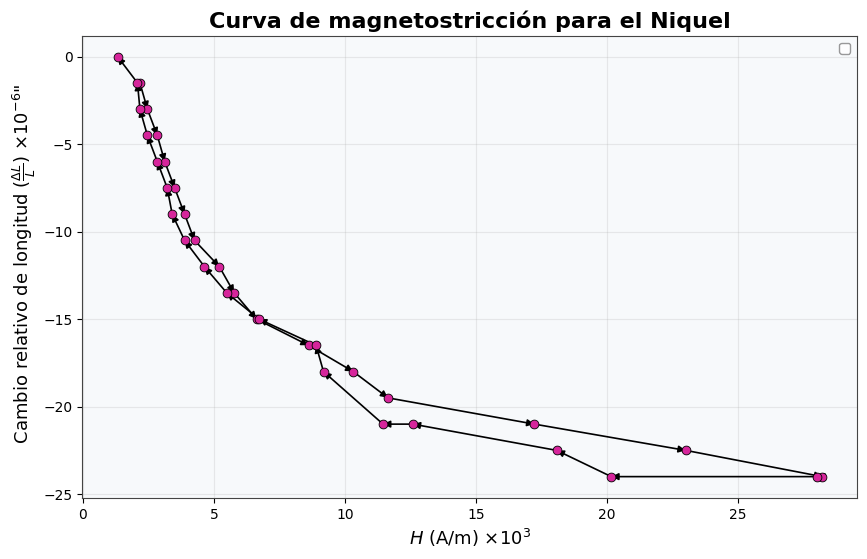

In [125]:
lambda_n = 6*10**-9 #nm
delta_l = lambda_n *niquel[1] / 2 
l= 0.1

H = B_to_H(conversion(niquel[0]))


plot_secuencia_datos(
    H*10**-3, delta_l/l*10**8,
    titulo="Curva de magnetostricción para el Niquel",
    xlabel = r"$H$ (A/m) $\times 10^{3}$",
    ylabel= r' Cambio relativo de longitud ($\frac{\Delta L}{L}$) $\times 10^{-6}$"',
    arrow_scale=0.15,
)


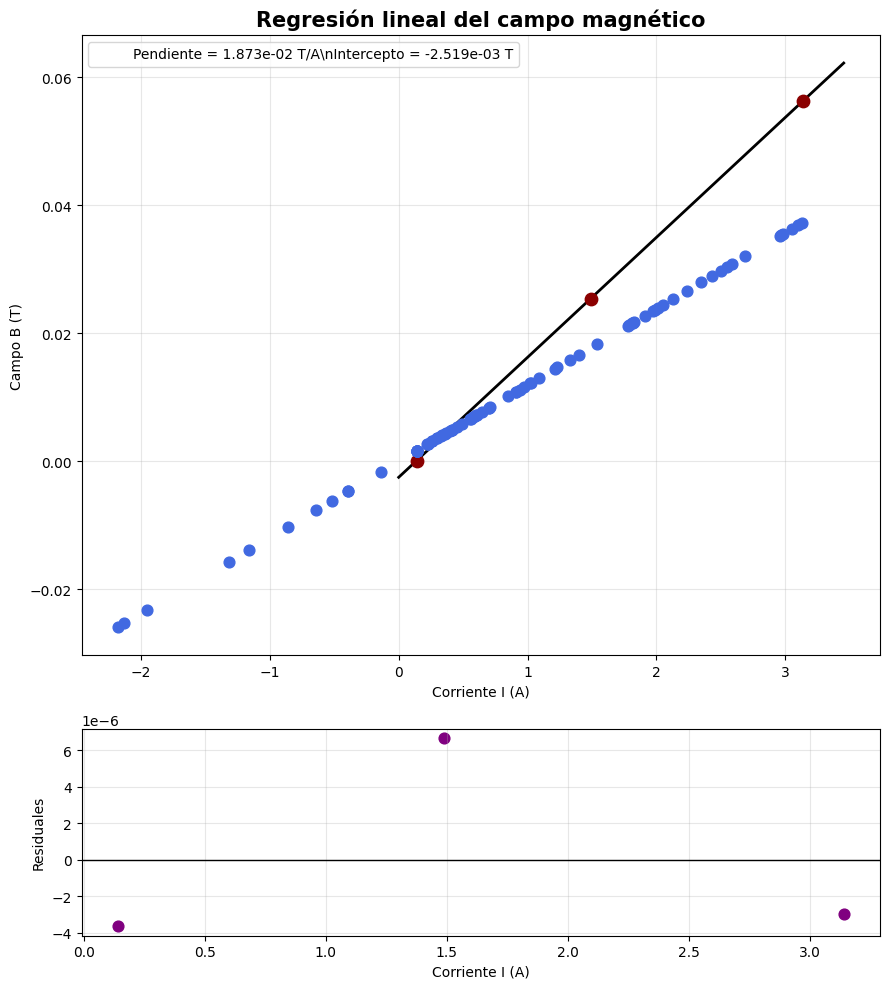

In [127]:
def plot_campo_magnetico(corrientes):
    """
    corrientes: array con las corrientes medidas en el laboratorio (A)
    Se grafican:
      - Puntos de calibración
      - Recta ajustada
      - Tus puntos convertidos (se usan de verdad)
    """

    # -------------------------------
    # Puntos de calibración
    # -------------------------------
    puntos_I = np.array([0.14, 1.49, 3.14])      # A
    puntos_B = np.array([0.1, 25.4, 56.3]) * 1e-3  # mT → T

    # -------------------------------
    # Ajuste lineal (solo calibración)
    # -------------------------------
    pendiente, intercepto = np.polyfit(puntos_I, puntos_B, 1)

    # -------------------------------
    # TUS puntos de corriente → B
    # -------------------------------
    valores = np.array([0.1/0.14, 25.4/1.49, 56.3/3.14])  # mT/A
    conversion_mT_A = np.mean(valores)

    B_tus_puntos = corrientes * conversion_mT_A * 1e-3  # mT→T

    # -------------------------------
    # Residuales de la regresión
    # -------------------------------
    ajuste_calibracion = pendiente * puntos_I + intercepto
    residuales = puntos_B - ajuste_calibracion

    # -------------------------------
    # FIGURA
    # -------------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 10), gridspec_kw={'height_ratios': [3, 1]}
    )

    # --- Puntos de calibración (rojos) ---
    ax1.scatter(
        puntos_I, puntos_B,
        color="darkred", s=80, zorder=5
    )

    # --- Tus puntos (azules) ---
    ax1.scatter(
        corrientes, B_tus_puntos,
        color="royalblue", s=60, zorder=6
    )

    # --- Recta ajustada ---
    I_line = np.linspace(0, 1.1*max(puntos_I), 200)
    ax1.plot(I_line, pendiente*I_line + intercepto, "black", linewidth=2)

    # --- Estética ---
    ax1.set_title("Regresión lineal del campo magnético", fontsize=15, weight="bold")
    ax1.set_xlabel("Corriente I (A)")
    ax1.set_ylabel("Campo B (T)")
    ax1.grid(alpha=0.3)

    # --- SOLO pendiente e intercepto en la leyenda ---
    ax1.plot([], [], ' ', 
             label=rf"Pendiente = {pendiente:.3e} T/A\nIntercepto = {intercepto:.3e} T")
    ax1.legend(frameon=True)

    # -------------------------------
    # Subplot de residuales
    # -------------------------------
    ax2.scatter(puntos_I, residuales, color="purple", s=60)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Corriente I (A)")
    ax2.set_ylabel("Residuales")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return pendiente, intercepto

puntos = np.concatenate([niquel[0], hierro[0]])
pend, inter = plot_campo_magnetico(puntos)